In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from diffusers import AutoPipelineForInpainting, EulerDiscreteScheduler
from diffusers.utils import load_image, make_image_grid
from simple_lama_inpainting import SimpleLama
from optimum.intel import OVStableDiffusionXLInpaintPipeline

Multiple distributions found for package optimum. Picked distribution: optimum
c:\Users\zeyad\miniconda3\envs\multimodal\Lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


In [3]:
init_image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png")
mask_image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png")

# init_image = init_image.resize((200, 200))
# mask_image = mask_image.resize((200, 200))

prompt = "a black cat with glowing eyes, cute, adorable, disney, pixar, highly detailed, 8k"
negative_prompt = "bad anatomy, deformed, ugly, disfigured"

Text(0.5, 1.0, 'final result')

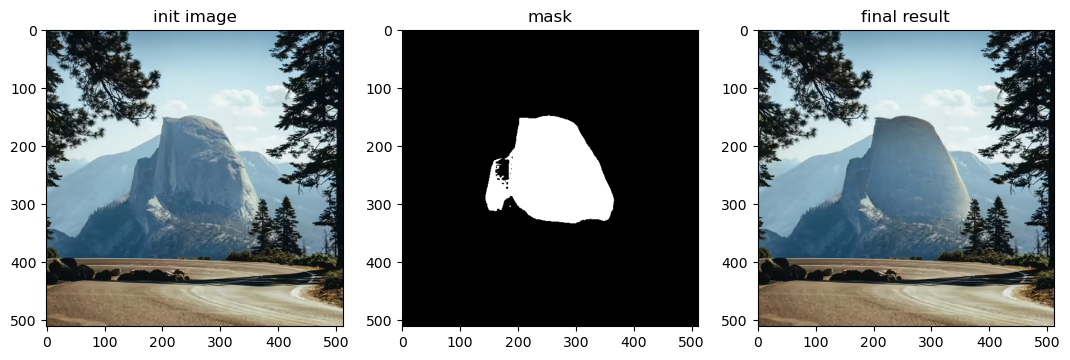

In [4]:
# LaMa: mask cleaning and object removal

# downloaded at C:\Users\zeyad\.cache\torch\hub\checkpoints
lama = SimpleLama()
result = lama(init_image, mask_image.convert("L"))


plt.figure(figsize=(13, 13))
plt.subplot(131)
plt.imshow(np.array(init_image))
plt.title("init image")

plt.subplot(132)
plt.imshow(np.array(mask_image))
plt.title("mask")

plt.subplot(133)
plt.imshow(np.array(result))
plt.title("final result")

In [ ]:
# SDXL-Lightning + OpenVINO (Highest Quality)

# Load the Intel-optimized version (first run downloads the converted model)
model_id = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = OVStableDiffusionXLInpaintPipeline.from_pretrained(
    model_id,
    device="CPU" # or "GPU"
)


image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=init_image,
    mask_image=mask_image,
    num_inference_steps=4,  # Only 4 steps!
    guidance_scale=0.0
).images[0]

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


openvino_model.bin:  31%|###       | 3.18G/10.3G [00:00<?, ?B/s]

Error while downloading from https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0/resolve/462165984030d82259a11f4367a4eed129e94a7b/unet/openvino_model.bin: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...


openvino_model.bin:  31%|###1      | 3.20G/10.3G [00:00<?, ?B/s]

...

openvino_model.bin:  33%|###3      | 3.43G/10.3G [00:00<?, ?B/s]

Error while downloading from https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0/resolve/462165984030d82259a11f4367a4eed129e94a7b/unet/openvino_model.bin: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...


openvino_model.bin:  34%|###3      | 3.46G/10.3G [00:00<?, ?B/s]

Error while downloading from https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0/resolve/462165984030d82259a11f4367a4eed129e94a7b/unet/openvino_model.bin: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...


openvino_model.bin:  34%|###3      | 3.46G/10.3G [00:00<?, ?B/s]

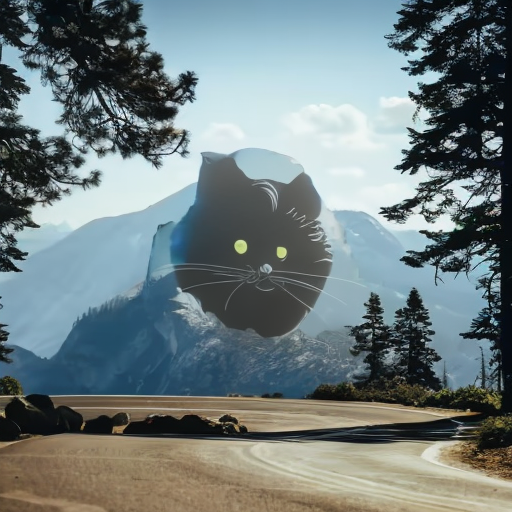

In [27]:
image